In [169]:
from lorenzo_utils import *
from visualization_utils import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

graph_path = DATA_DIR + 'Centrality/Centrality_climate_19.graphml'
G = load_graph(graph_path)



Genero i due sottografi

In [164]:
nodi_A = G.vs.select(group="A")
G_A = G.subgraph(nodi_A)
nodi_B = G.vs.select(group="B")
G_B = G.subgraph(nodi_B)

# Statistica del network

In [81]:
def network_statistics(G):
    N = G.vcount()
    L = G.ecount()
    rho = G.density()
    avg_degree = 2 * L / N
    avg_clustering = G.transitivity_avglocal_undirected() # coefficiente di clustering medio
    diametro = G.diameter() # diametro del grafo


    return {
        "Numero di Nodi": N,
        "Numero di Archi": L,
        "Densità del Grafo": rho,
        "Grado Medio": avg_degree,
        "Clustering Medio": avg_clustering,
        "Diametro": diametro 
    }


In [82]:
def print_network_statistics(G):
    stat = network_statistics(G)
    print("        STATISTICHE DEL NETWORK        ")
    print("-"*40)
    for key, value in stat.items():
        print(f"{key}: {value}")
        
    print("-"*40)


In [4]:
print_network_statistics(G)

        STATISTICHE DEL NETWORK        
----------------------------------------
Numero di Nodi: 16639
Numero di Archi: 50605
Densità del Grafo: 0.0003655906525712596
Grado Medio: 6.082697277480618
Clustering Medio: 0.17544907339858107
Diametro: 13
----------------------------------------


In [ ]:
stats_A = network_statistics(G_A)
stats_B = network_statistics(G_B)

print("SOTTOGRAFO A")
print_network_statistics(G_A)
print("\nSOTTOGRAFO B")
print_network_statistics(G_B)

SOTTOGRAFO A
        STATISTICHE DEL NETWORK        
----------------------------------------
Numero di Nodi: 7409
Numero di Archi: 28384
Densità del Grafo: 0.0010342916661686635
Grado Medio: 7.6620326629774596
Clustering Medio: 0.2572179272650303
Diametro: 12
----------------------------------------

SOTTOGRAFO B
        STATISTICHE DEL NETWORK        
----------------------------------------
Numero di Nodi: 9230
Numero di Archi: 17487
Densità del Grafo: 0.00041057165064618605
Grado Medio: 3.789165763813651
Clustering Medio: 0.12504484957300033
Diametro: 14
----------------------------------------


# Calcolo delle metriche e aggiornamento su file

In [3]:
COMPUTE_CENTRALITY = False
if COMPUTE_CENTRALITY:
    from sys import stdout
    for graph_file in GRAPH_FILENAMES:
        print('loading:', graph_file)
        stdout.flush()
        G = load_graph(DATA_DIR + graph_file)
        load_all_centralities(G, dumpfile=DATA_DIR+'Centrality/Centrality_'+graph_file)
        print('saved centrality')

# CCDF (Complementary cumulative distribution)

In [46]:
def plot_ccdf(G: ig.Graph, metric: str='degree', log: bool=True, save=False):
    values = np.array(G.vs[metric])
    k_values, ccdf = compute_ccdf(values)
    kA_values, ccdfA = compute_ccdf(values[[group == 'A' for group in G.vs['group']]])
    kB_values, ccdfB = compute_ccdf(values[[group == 'B' for group in G.vs['group']]])

    fig, ax = plt.subplots(figsize=FIGSIZE, sharex=True, layout='tight')
    ax.plot(k_values, ccdf, marker='.', linewidth='2', markersize='0.3', color = 'black', alpha=0.7,label='Tot')
    ax.plot(kA_values, ccdfA, marker='.', linewidth='2', markersize='0.3', color = color_group['A'], label='A')
    ax.plot(kB_values, ccdfB, marker='.', linewidth='2', markersize='0.3', color = color_group['B'], label='B')
    ax.set_title(metric + ' complementary cumulative distribution')
    ax.set_xlabel(metric)
    ax.set_ylabel('ccdf')
    fig.legend(frameon=False, bbox_to_anchor=(0.99,0.9), loc='upper right')
    if log:
        ax.set_xscale('log')
        ax.set_yscale('log')
    if save:
        plt.savefig(f'ccdf_{metric}.png')    
    plt.show()    
    plt.close(fig)   

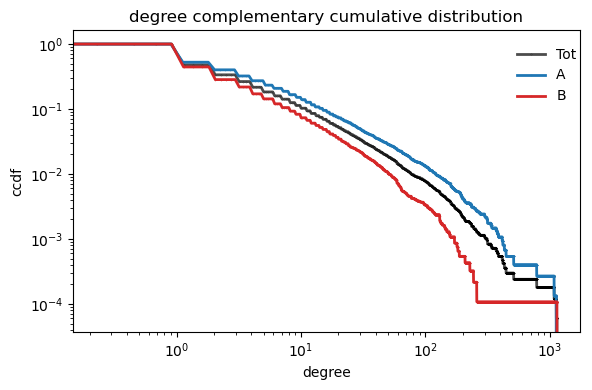

In [47]:
plot_ccdf(G, 'degree', log=True)

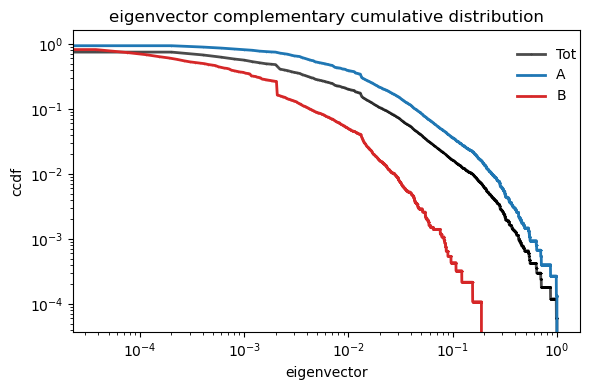

In [48]:
plot_ccdf(G, 'eigenvector', log=True)

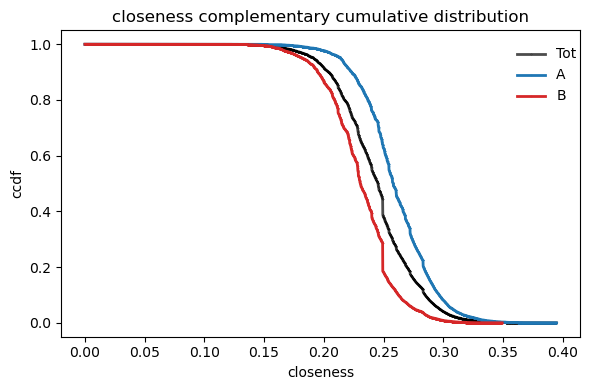

In [49]:
plot_ccdf(G, 'closeness', log=False)

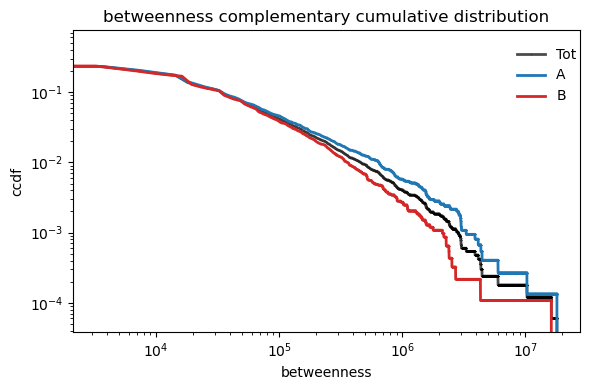

In [50]:
plot_ccdf(G, 'betweenness', log=True)

# Scatter plot

In [ ]:
def plot_metric_vs_metric(G, metric_x, metric_y, color=cmap(0)):
    fig, ax = plt.subplots(figsize=FIGSIZE, sharex=True, layout='tight')
    ax.scatter(G.vs[metric_x], G.vs[metric_y], s=0.3, color=color)
    ax.set_title(f'{metric_y} vs {metric_x}')
    ax.set_xlabel(metric_x)
    ax.set_ylabel(metric_y)
    ax.set_xscale('log')
    ax.set_yscale('log')
    plt.savefig(f'{metric_y}_vs_{metric_x}.png')
    plt.show()
    
    return fig, ax
    plt.close(fig)

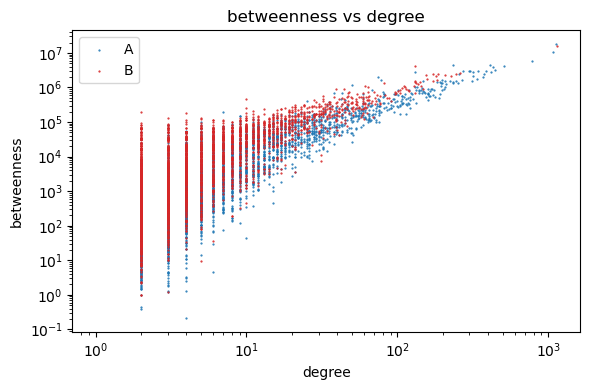

In [90]:
def plot_metric_vs_metric_AB(G, metric_x, metric_y, ax, group:str):
    ax.scatter(G.vs[metric_x], G.vs[metric_y], s=0.3, color=color_group[group], label=group)
    ax.set_title(f'{metric_y} vs {metric_x}')
    ax.set_xlabel(metric_x)
    ax.set_ylabel(metric_y)
    ax.legend()
    ax.set_xscale('log')
    ax.set_yscale('log')

fig, ax = plt.subplots(figsize=FIGSIZE, sharex=True, layout='tight')
plot_metric_vs_metric_AB(G_A, 'degree', 'betweenness', ax, group='A')
plot_metric_vs_metric_AB(G_B, 'degree', 'betweenness', ax, group='B')



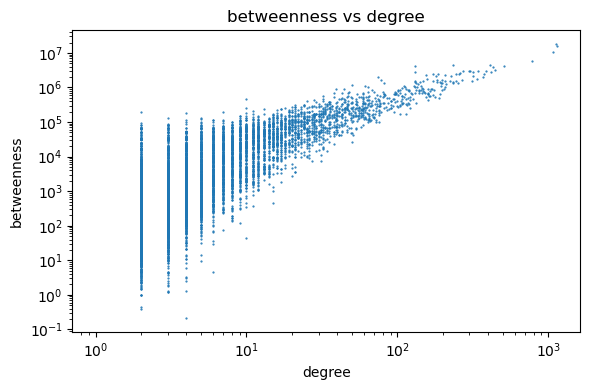

In [28]:
plot_metric_vs_metric(G, 'degree', 'betweenness')

# Distribuzioni di misure di centralità

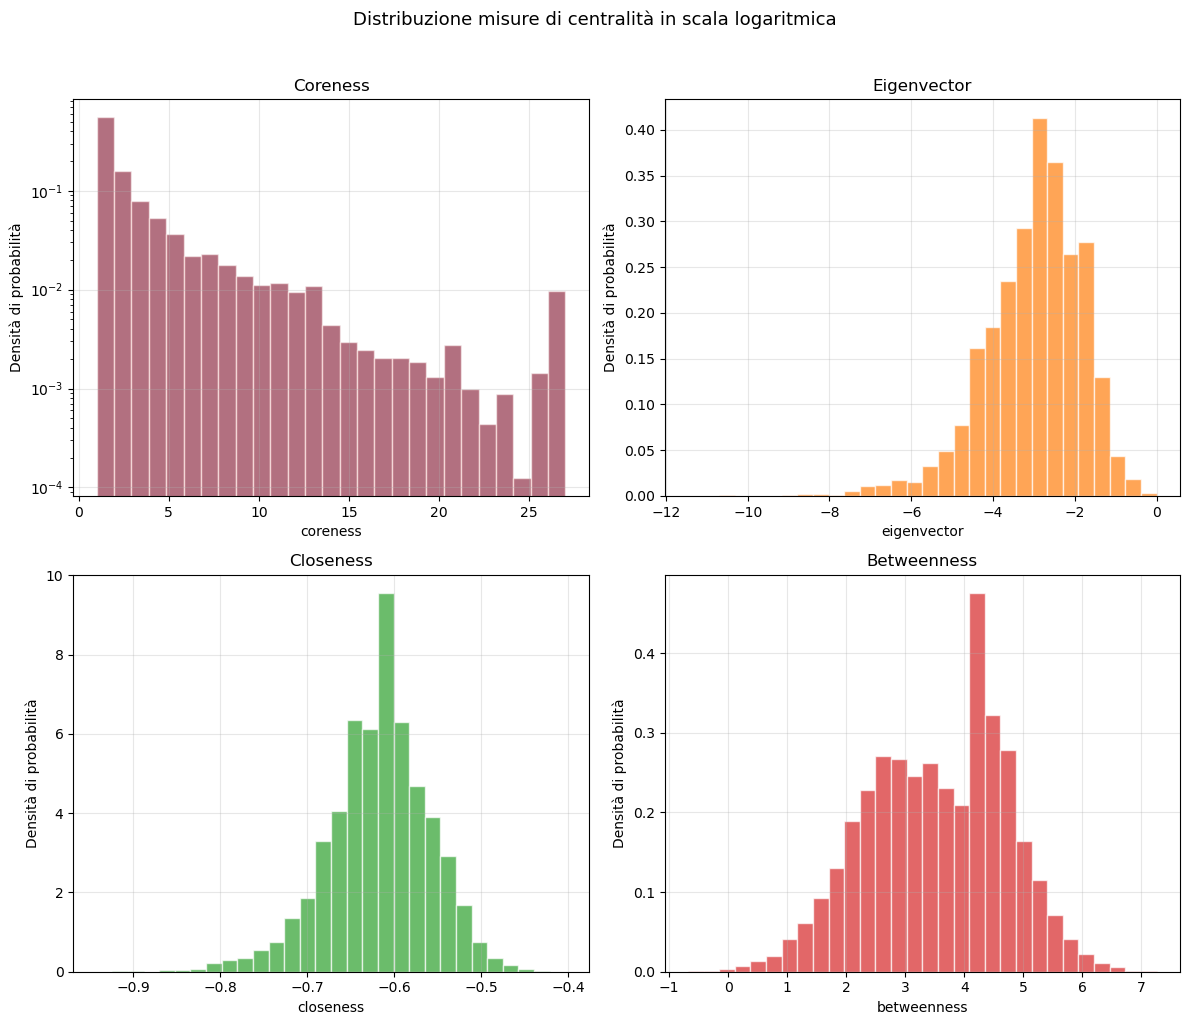

In [57]:
metrics = ['coreness', 'eigenvector', 'closeness', 'betweenness']
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_LARGE, layout='tight')
colors = [cmap(i) for i in range(len(metrics))]

for ax, m, color in zip(axes.flat, metrics, colors):
    
    values = np.array(G.vs[m], dtype=float)
    values = values[values > 0]

    if m == 'coreness':
        ax.hist(values, bins=27, density=True,
                color=cmap(0), alpha=0.5, edgecolor='white', label='A')
        ax.hist(values, bins=27, density=True,
                color=cmap(3), alpha=0.5, edgecolor='white', label='B')
        ax.set_yscale('log')
    else:    
        ax.hist(np.log10(values), bins=30, density=True,
                color=color, alpha=0.7, edgecolor='white')
    ax.set_title(m.capitalize())
    ax.set_xlabel(m)
    ax.set_ylabel("Densità di probabilità" )
    ax.grid(alpha=0.3)
    

fig.suptitle("Distribuzione misure di centralità in scala logaritmica", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
plt.close(fig)

Domanda:
sono gli stessi nodi a generare i picchi nei vari grafici?

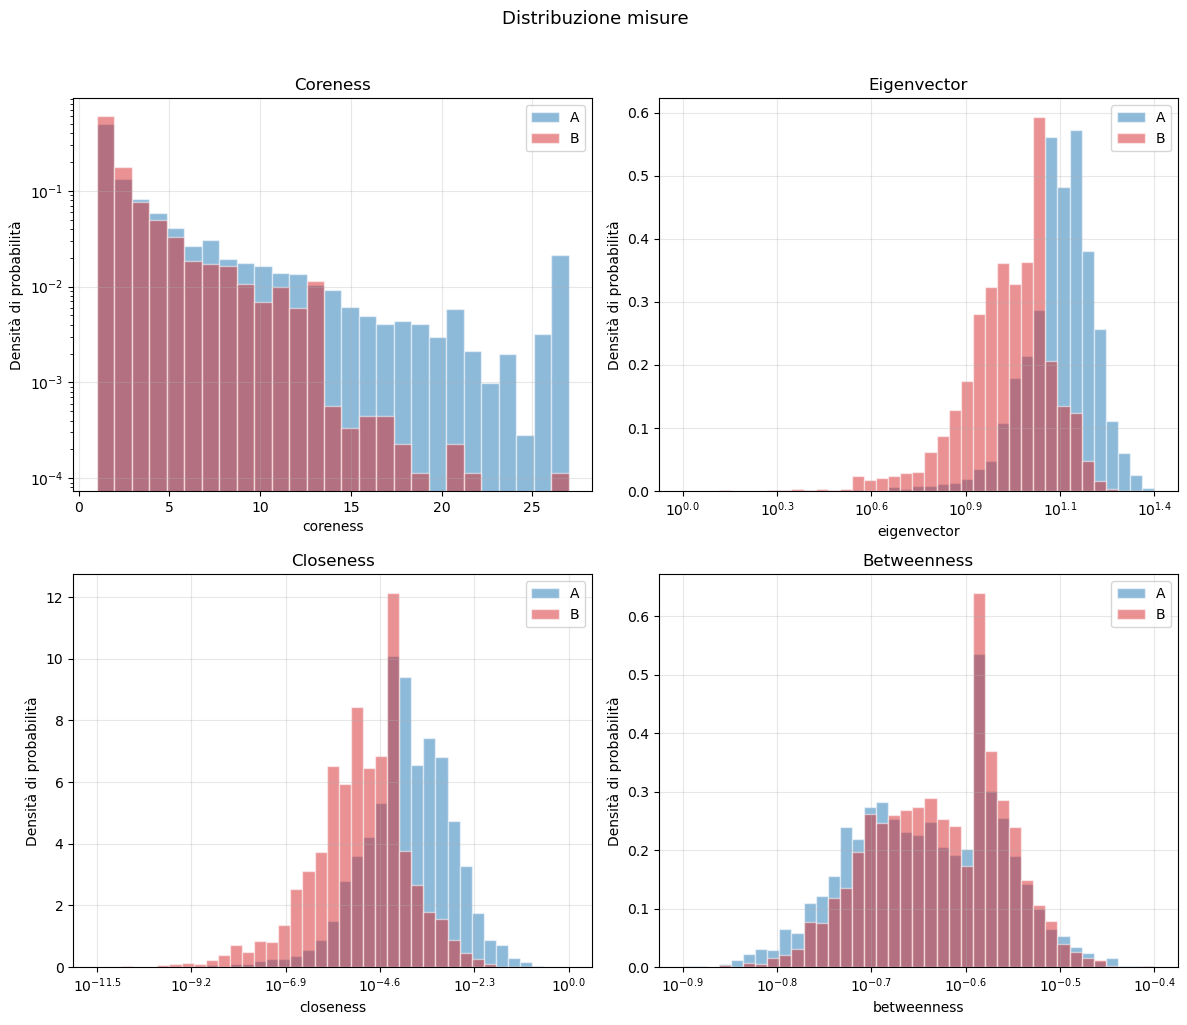

In [81]:
metrics = ['coreness', 'eigenvector', 'closeness', 'betweenness']
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_LARGE)


for ax, m in zip(axes.flat, metrics):
    values = np.array(G.vs[m], dtype=float)

    valuesA = np.array(values[[group == 'A' for group in G.vs['group']]])
    valuesB = np.array(values[[group == 'B' for group in G.vs['group']]])
    valuesA = valuesA[valuesA > 0]
    valuesB = valuesB[valuesB > 0]
    x_ticks_log = np.linspace(all_vals.min(), all_vals.max(), 6)
    x_ticks_original = 10 ** x_ticks_log  # valori originali corrispondenti

    all_vals = np.concatenate([np.log10(valuesA), np.log10(valuesB)])
    bins = np.linspace(all_vals.min(), all_vals.max(), 40) 
    

    if m == 'coreness':  # coreness è già in scala discreta, non ha senso logaritmizzarla
        ax.hist(valuesA, bins=27, density=True,
                color=color_group['A'], alpha=0.5, edgecolor='white', label='A')
        ax.hist(valuesB, bins=27, density=True,
                color=color_group['B'], alpha=0.5, edgecolor='white', label='B')
        ax.set_yscale('log')

    else:
        ax.hist(np.log10(valuesA), bins=bins, density=True,
                color=color_group['A'], alpha=0.5, edgecolor='white', label='A')
        ax.hist(np.log10(valuesB), bins=bins, density=True,
                color=color_group['B'], alpha=0.5, edgecolor='white', label='B')
        ax.set_xticks(np.linspace(all_vals.min(), all_vals.max(),6))
        ax.set_xticklabels([f"$10^{{{v:.1f}}}$" for v in x_ticks_log])
    ax.set_title(m.capitalize())
    ax.tick_params(direction='out')
    
    ax.set_xlabel(m)
    ax.set_ylabel("Densità di probabilità")
    ax.grid(alpha=0.3)
    ax.legend()




fig.savefig("centralities.png")
fig.suptitle("Distribuzione misure", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
plt.close(fig)

- **CORENESS** 
Il gruppo A domina i k-core alti (coreness 10–27), mentre B è quasi assente oltre il 15. Questo indica che A forma un nucleo densamente interconnesso, un "inner circle" di utenti che si ritwittano a vicenda intensamente. B invece è più periferico, con molti nodi a basso coreness. È un segnale classico di **echo chamber asimmetrica**: A ha una comunità più coesa e organizzata.
- **EIGENVECTOR**
B ha la distribuzione spostata verso sinistra (valori più negativi = centralità più bassa), A verso destra. Significa che i nodi di A sono connessi ad altri nodi influenti, mentre B ha nodi influenti più isolati o connessi a nodi periferici. In un grafo di retweet politico, questo può indicare che le figure chiave di A amplificano reciprocamente il loro messaggio più efficacemente.
- **CLOSENESS**
A è spostato verso destra (valori meno negativi = closeness più alta). I nodi di A raggiungono il resto del grafo in meno passi: sono meglio posizionati per diffondere informazioni a tutto il network. B ha closeness più bassa e più dispersa, suggerendo una struttura più frammentata.
- **BETWEENNESS**
Qui la differenza è più sottile, ma A tende ad avere betweenness leggermente più alta e con coda più lunga verso destra. Ci sono nodi di A che fungono da **broker o ponti** nella rete. Interessante: se ci sono nodi B con alta betweenness, potrebbero essere utenti che "attraversano" le due bolle (cross-cutting), vale la pena identificarli.

## Degree distribution

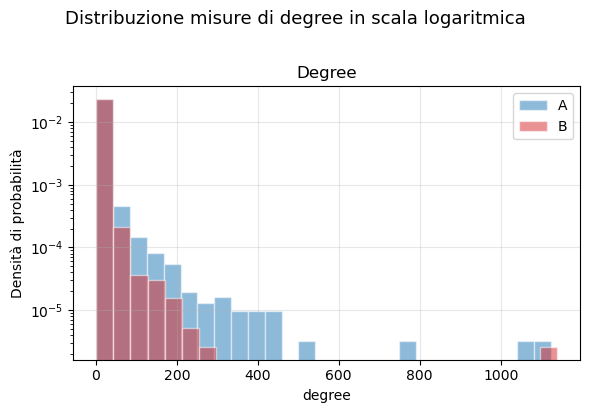

In [29]:
m = 'degree'
fig, ax = plt.subplots(figsize=FIGSIZE)

values = np.array(G.vs[m], dtype=float)
valuesA = np.array(values[[group == 'A' for group in G.vs['group']]])
valuesB = np.array(values[[group == 'B' for group in G.vs['group']]])
valuesA = valuesA[valuesA > 0]
valuesB = valuesB[valuesB > 0]


ax.hist(valuesA, bins=27, density=True,
        color=color_group['A'], alpha=0.5, edgecolor='white', label='A')
ax.hist(valuesB, bins=27, density=True,
        color=color_group['B'], alpha=0.5, edgecolor='white', label='B')
ax.set_yscale('log')

ax.set_title(m.capitalize())
ax.set_xlabel(m)
ax.set_ylabel("Densità di probabilità")
ax.grid(alpha=0.3)
ax.legend()

fig.suptitle(f"Distribuzione misure di {m} in scala logaritmica", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{m}_distribution.png')
plt.show()

plt.close(fig)

# Coreness

In [146]:
G.vs['coreness'] = G.coreness()

In [16]:
max_coreness = max(G.vs['coreness'])
nodes_in_max_core = G.vs.select(coreness_ge=max_coreness)
main_core = G.subgraph(nodes_in_max_core)
print(f"Il core massimo ha k = {max_coreness} e contiene {main_core.vcount()} nodi.")

Il core massimo ha k = 27 e contiene 155 nodi.


In [183]:
def subgraph_core(G, K_core, plot=True):
    nodes_in_core = G.vs.select(coreness_ge=K_core)
    subgraph_core = G.subgraph(nodes_in_core)
    print(f"Il core ha k = {K_core} e contiene {subgraph_core.vcount()} nodi.")
    if plot:
        plot_group_AB(subgraph_core, save=False, only_periphery=False, niter=None)
        plt.show()
        plt.close(fig) 
    return subgraph_core    

Il core ha k = 10 e contiene 1223 nodi.
Gruppi trovati: ['A', 'B']


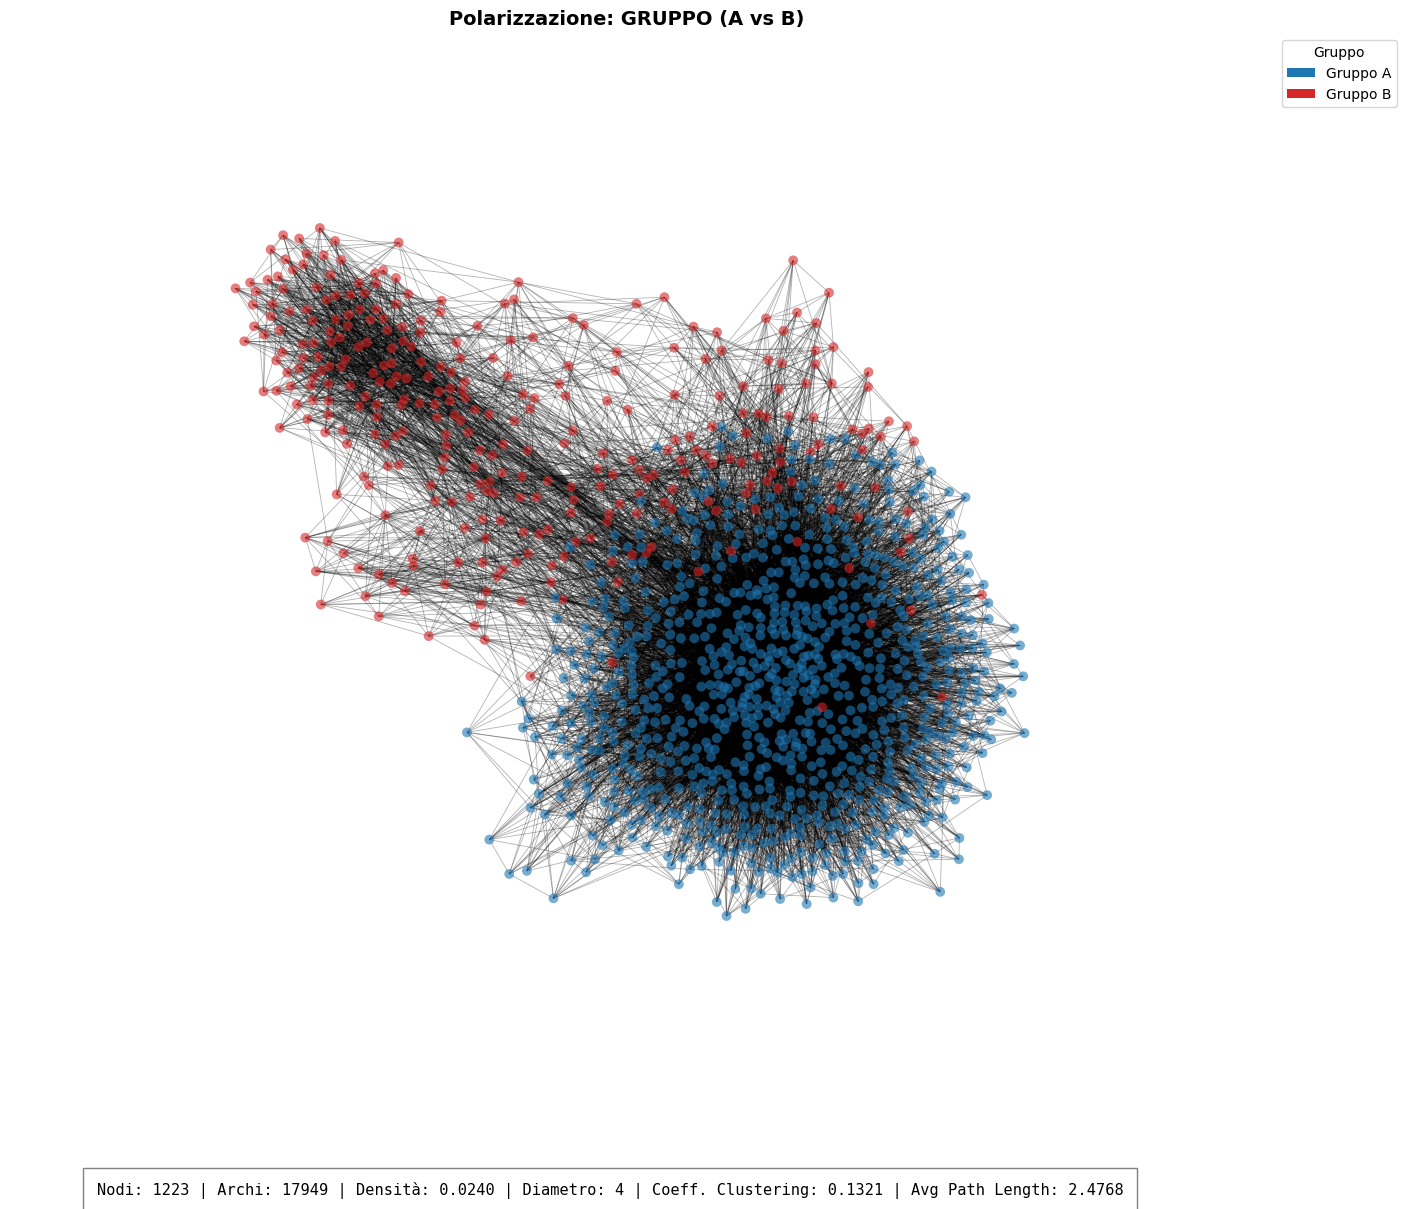

In [184]:
subgraph_kcore = subgraph_core(G, K_core=10)

Il core ha k = 27 e contiene 155 nodi.
Gruppi trovati: ['A', 'B']


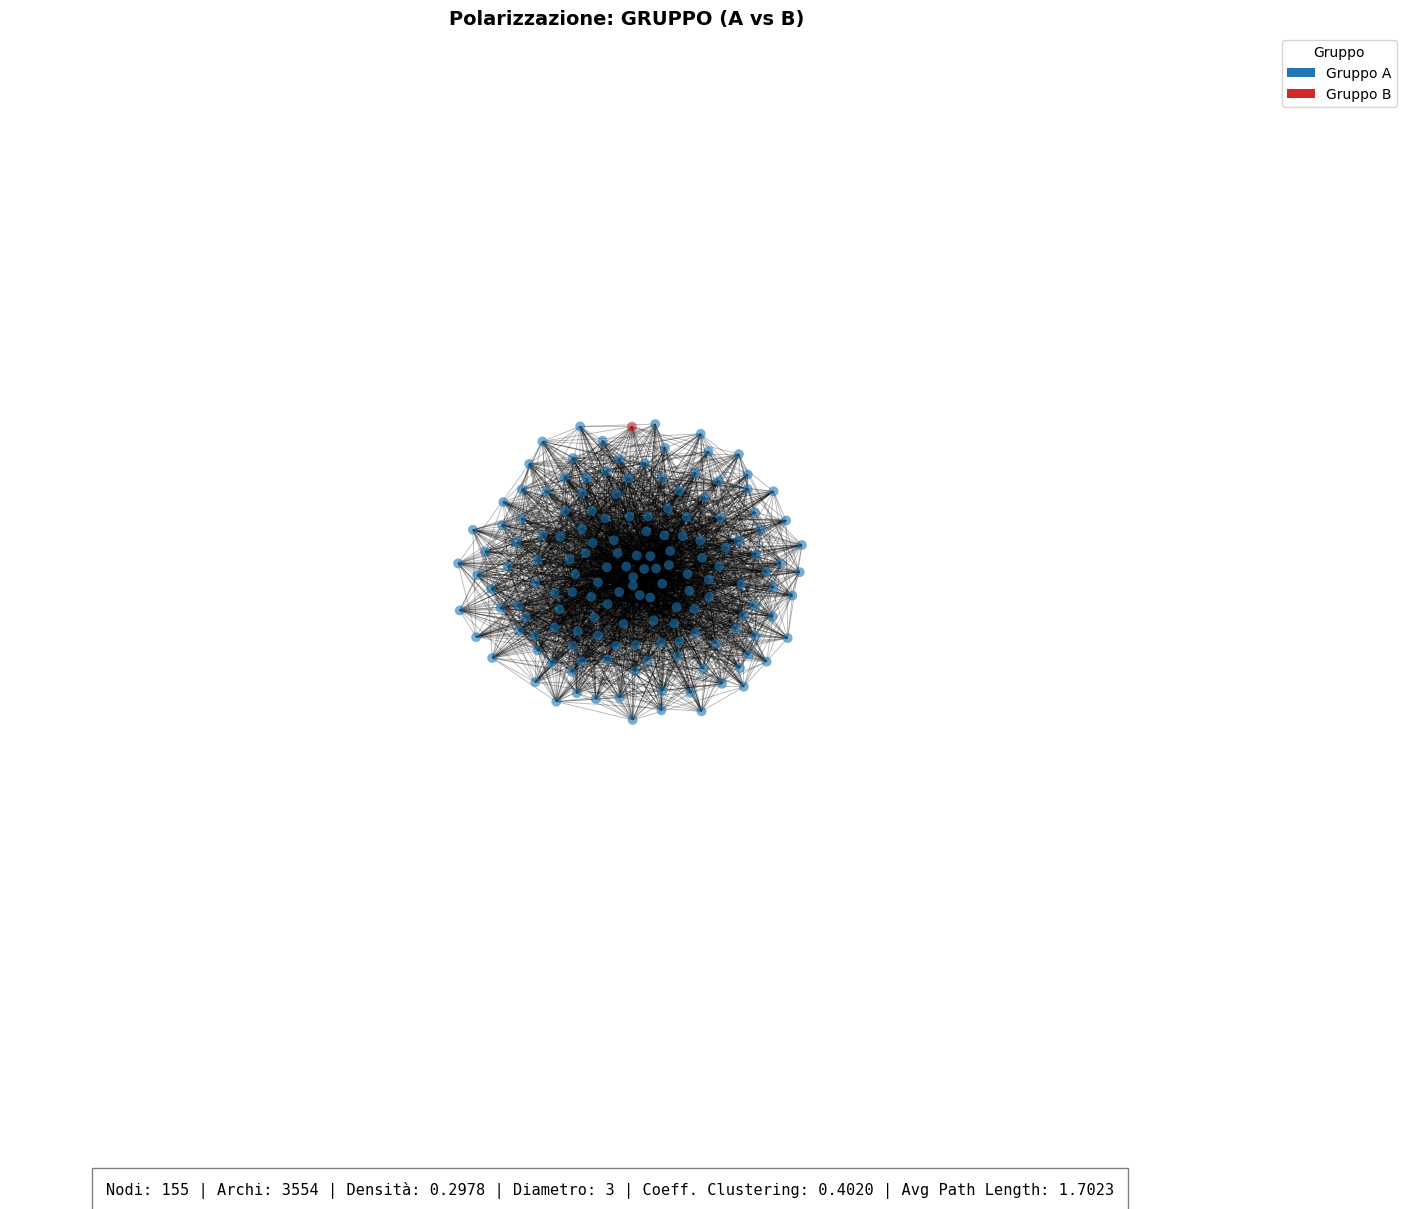

In [35]:
plot_subgraph_core(G, K_core=max_coreness)

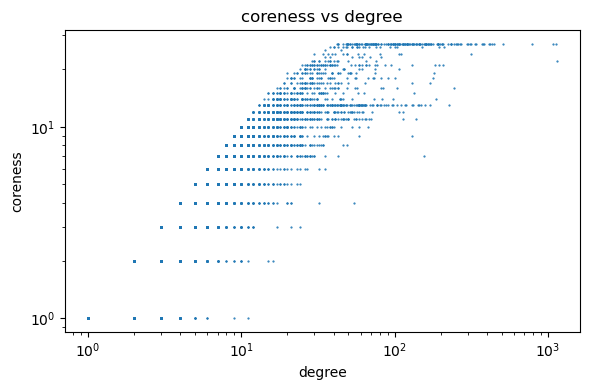

In [30]:
# coreness vs degree
plot_metric_vs_metric(G, 'degree', 'coreness')

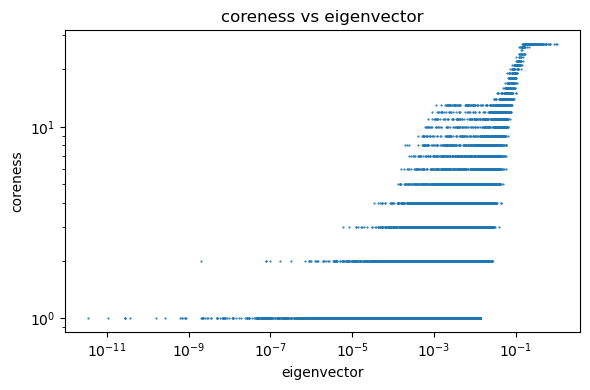

In [31]:
# coreness vs eigenvector
plot_metric_vs_metric(G, 'eigenvector', 'coreness')

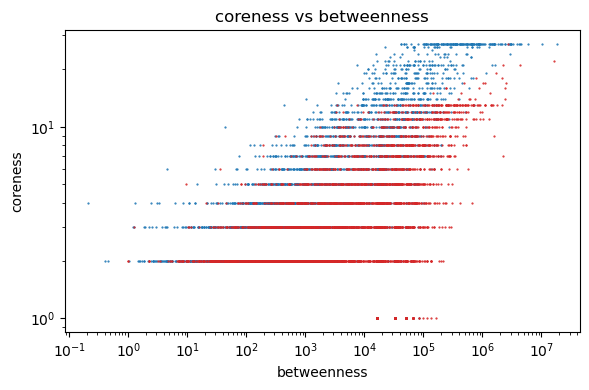

In [ ]:
# coreness vs betweenness
fig, ax = plt.subplots(figsize=FIGSIZE, sharex=True, layout='tight')
plot_metric_vs_metric_AB(G_A, 'coreness', 'betweenness', ax, color=color_group['A'])
plot_metric_vs_metric_AB(G_B, 'coreness', 'betweenness', ax, color=color_group['B'])


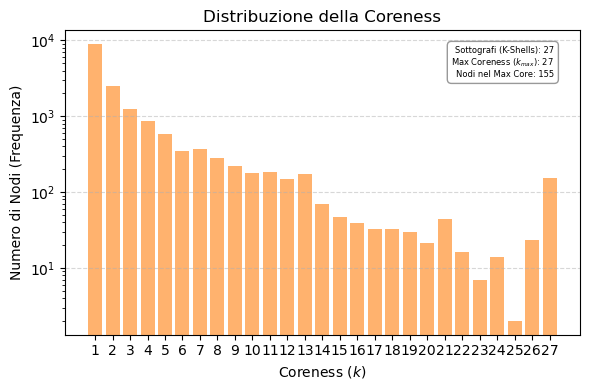

In [ ]:
from collections import Counter
# Conta le frequenze di ciascun livello di k
counts = Counter(G.vs['coreness'])
ks = sorted(counts.keys())
frequencies = [counts[k] for k in ks]

fig, ax = plt.subplots(figsize=FIGSIZE, sharex=True, layout='tight')

# Grafico a barre
ax.bar(ks, frequencies, color=cmap(1), alpha=0.6)

# Ottimizzazione assi e griglia
ax.set_xlabel("Coreness ($k$)")
ax.set_ylabel("Numero di Nodi (Frequenza)")
ax.set_title("Distribuzione della Coreness")

# Usa scala logaritmica sull'asse Y se la periferia schiaccia troppo il grafico
ax.set_yscale('log') 

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_xticks(ks if len(ks) < 30 else np.arange(min(ks), max(ks)+1, max(ks)//10))

# Box informativo con metriche chiave
info_text = f"Sottografi (K-Shells): {len(ks)}\nMax Coreness ($k_{{max}}$): {max(ks)}\nNodi nel Max Core: {counts[max(ks)]}"
ax.text(0.95, 0.95, info_text, transform=ax.transAxes, fontsize=6,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()

plt.show()

plt.close(fig)

# Spearman rank

In [43]:
from scipy.stats import spearmanr

metrics = ['degree', 'eigenvector', 'closeness', 'betweenness']
df = pd.DataFrame({m: G.vs[m] for m in metrics})

# --- Matrice di correlazione di Spearman ---
corr_matrix, p_matrix = spearmanr(df)
corr_df = pd.DataFrame(corr_matrix, index=metrics, columns=metrics)

print(corr_df.round(3))

             degree  eigenvector  closeness  betweenness
degree        1.000        0.549      0.596        0.943
eigenvector   0.549        1.000      0.979        0.470
closeness     0.596        0.979      1.000        0.522
betweenness   0.943        0.470      0.522        1.000


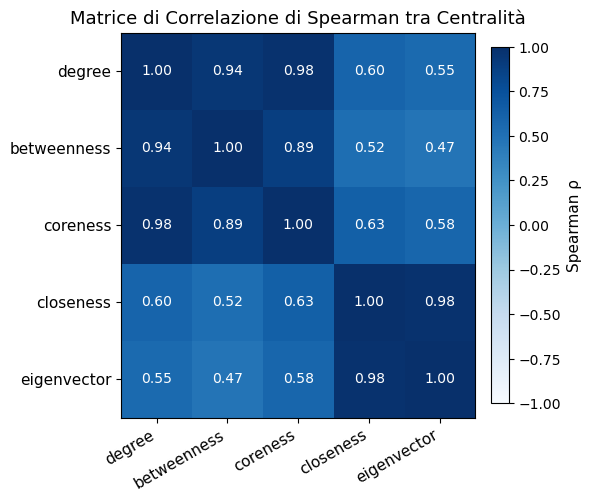

In [33]:
from scipy.stats import spearmanr
import matplotlib.colors as mcolors


# --- 2. Calcola le centralità ---
centralities = {
    'degree':      G.vs['degree'],
    'betweenness': G.vs['betweenness'],
    'coreness':    G.vs['coreness'],
    'closeness':   G.vs['closeness'],
    'eigenvector': G.vs['eigenvector'],
    
}

labels = list(centralities.keys())
n = len(labels)
data = np.array([centralities[k] for k in labels])  # shape (4, n_nodes)

# --- 3. Matrice di correlazione di Spearman ---
corr_matrix = np.ones((n, n))
pval_matrix = np.ones((n, n))

for i in range(n):
    for j in range(i + 1, n):
        r, p = spearmanr(data[i], data[j])
        corr_matrix[i, j] = r
        corr_matrix[j, i] = r
        pval_matrix[i, j] = p
        pval_matrix[j, i] = p

# --- 4. Plot heatmap con matplotlib puro ---
fig, ax = plt.subplots(figsize=(5, 5))

# Colormap divergente centrata su 0
vmin, vmax = -1, 1
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

im = ax.imshow(corr_matrix, cmap=CMAP_HEAT, norm=norm, aspect='auto')

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Spearman ρ", fontsize=11)

# Etichette assi
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
ax.set_title("Matrice di Correlazione di Spearman tra Centralità", fontsize=13)

low = corr_matrix.min() if vmin is None else vmin
high = corr_matrix.max() if vmax is None else vmax
threshold = (low + high) / 2.0 if high > low else high
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        value = corr_matrix[i, j]
        text_color = 'white' if value >= threshold else 'black'
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha='center',
            va='center',
            color=text_color,
        )
plt.savefig('correlation_heatmap.png')        
plt.show()

plt.close(fig)        

# Confronto con modelli nulli

In [2]:
import random
 
random.seed(0)

In [26]:
n_nodi = G.vcount()
m_edges = G.ecount()

mean_degree = m_edges * 2 / n_nodi
print(f"La rete in analisi ha {n_nodi} nodi e {m_edges} edges")

# genero grafo con Erdos Renyi
G_er = ig.Graph.Erdos_Renyi(n=n_nodi, m=m_edges)
# genero grafo con Barabasi-Albert
G_ba = ig.Graph.Barabasi(n_nodi, max(1, round(mean_degree / 2)))

G_er.vs['degree'] = G_er.degree()
G_ba.vs['degree'] = G_ba.degree()


La rete in analisi ha 16639 nodi e 50605 edges


In [75]:
def plot_ccdf_random_model(G: ig.Graph | list[ig.Graph], metric: str='degree', log: bool=True, savefile='', title='', legend=None):
    
    if isinstance(G, ig.Graph):
        G = [G]
    if legend is None:
        legend = [str(i) for i in range(1,len(G)+1)]
        
    fig, ax = plt.subplots(1,2, figsize=(12,5))
    for graph, color, label in zip(G, (cmap(0), cmap(1), cmap(2)), legend):
        values = np.array(graph.vs[metric])
        values = np.sort(values)[::-1]
        k_values, ccdf = compute_ccdf(values)
        ax[0].plot(k_values, ccdf, marker='o', markersize=1, linewidth=0.8, color = color, label=label)
        ax[0].set_xlabel(metric)
        ax[0].set_ylabel('ccdf')
        if log:
            ax[0].set_xscale('log')
            ax[0].set_yscale('log')
        ax[1].plot(np.arange(1,len(values)+1), values, marker='o', markersize=1, linewidth=0.8, color = color, label=label)
        ax[1].set_xlabel(metric)
        ax[1].set_ylabel('Rank')    
        

        if log:
            ax[1].set_xscale('log')
            ax[1].set_yscale('log')

    ax[0].legend(frameon=False, bbox_to_anchor=(0.99,0.9), loc='upper right')
    ax[1].legend(frameon=False, bbox_to_anchor=(0.99,0.9), loc='upper right')   
    
    if title:
        fig.suptitle(title)
    else:
        fig.suptitle(metric + ' complementary cumulative distribution')
    if savefile:
        plt.savefig(savefile)
    else:
        plt.show()

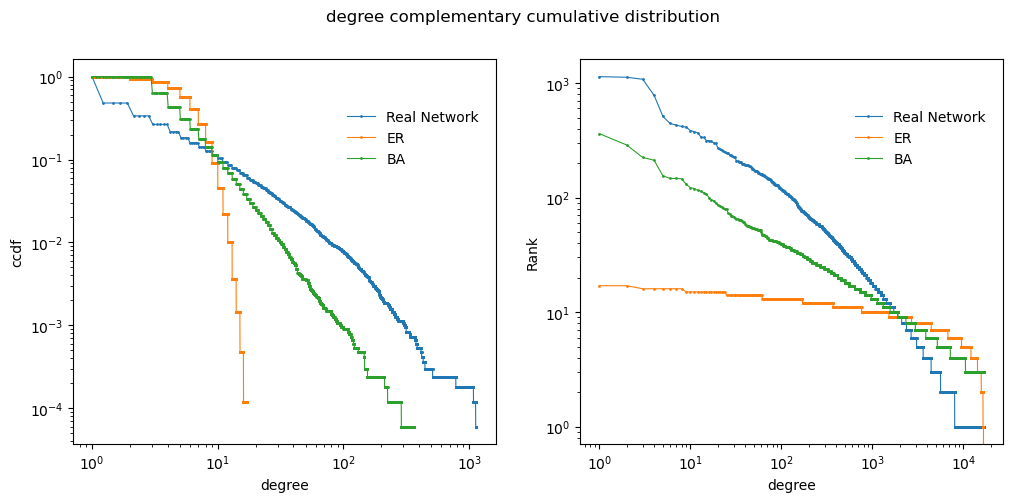

In [76]:
plot_ccdf_random_model([G, G_er, G_ba], metric='degree', legend=('Real Network', 'ER', 'BA'))

# Omofilia e Polarizzazione

## Degree correlation function
knn(k): media del grado medio dei vicini di un nodo con grado k

In [12]:
from scipy.stats import linregress

In [92]:
def compute_knn(G):
    knn_node, knn_degree = G.knn()
    k = []
    knn = []

    for k_val, val in enumerate(knn_degree):
        # Consideriamo solo i gradi esistenti nella rete (valori non nulli/NaN)

        if val > 0 and k_val >0 and not np.isnan(val):
            k.append(k_val)
            knn.append(val)
    return np.array(k), np.array(knn)

def plot_knn(G: ig.Graph | list[ig.Graph], legend=None):
    
    summary = []

    if isinstance(G, ig.Graph):
        G = [G]

    if legend is None:
        legend = [str(i) for i in range(1,len(G)+1)]    

    fig, ax = plt.subplots(figsize=FIGSIZE)

    
    for graph, color, label in zip(G, (color_group['A'], color_group['B']), legend):

        r = graph.assortativity_degree(directed=False) 
        k, knn = compute_knn(graph)
        slope, intercept, R, p, _ = linregress(np.log10(k), np.log10(knn))
        xline = np.linspace(k.min(), k.max(), 100)
        ax.plot(xline, 10**intercept * (xline**slope), linestyle='--', linewidth=1.6, label=f"r={slope:.2f}")
        


        ax.scatter(k, knn, s=1, color=color, label=label)
        ax.set_xscale('log')
        ax.set_yscale('log')  
        ax.set_xlabel("k")
        ax.set_ylabel("knn(k)")  
        ax.text(0.1, 0.1, ("Assortativa" if slope > 0 else "Disassortativa"),
            transform=ax.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='left',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))
        
        print(f"Grafo: {label}: r={r:.4f}, slope={slope:.4f}")
    
    fig.suptitle("Degree correlation function knn(k)")
    
    ax.legend()
    plt.savefig('knn_plot.png')
    plt.show()
    


Grafo: g: r=-0.1398, slope=-0.3280 con p-value=7.58470517788792e-19


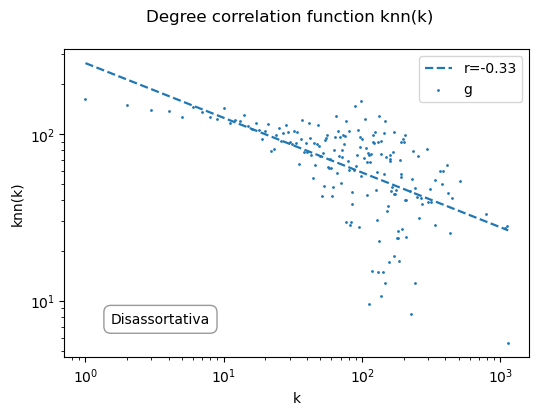

In [91]:
plot_knn(G, legend='global')

Grafo: A: r=-0.1961, slope=-0.3623
Grafo: B: r=-0.0988, slope=-0.4711


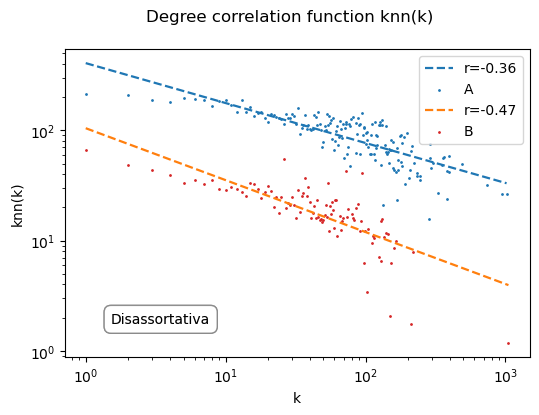

In [88]:
plot_knn([G_A, G_B], legend=['A','B'])

## Shuffle delle label

In [99]:
# manteniamo il numero di nodi nei due gruppi fissati
n_A = G_A.vcount()
n_B = G_B.vcount()

print(f"Nodi nel gruppo A: {n_A}\nNodi nel gruppo B: {n_B}")

Nodi nel gruppo A: 7409
Nodi nel gruppo B: 9230


In [ ]:
def cross_type_fraction(G: ig.Graph, attr_map):
    cross = sum(1 for u, v in G.get_edgelist() if attr_map[u] != attr_map[v])
    return cross / G.ecount()


def permutation_test(G: ig.Graph, n_perm=2000):
    group_label = np.array([1 if v == 'A' else 0 for v in G.vs['group']]) 
    observed = cross_type_fraction(G, group_label)
    results_simulated = np.zeros(n_perm)
    
    for i in range(n_perm):
        np.random.shuffle(group_label)
        results_simulated[i]=cross_type_fraction(G, group_label)
        if not i % 200:
            print("Running...\nPermutation n.", i)

    p_value = ( np.sum(results_simulated<=observed) + 1 ) / ( n_perm + 1 )   

    return observed, results_simulated, p_value

In [185]:
k_core = 10
subgraph = subgraph_core(G, K_core=k_core, plot=False)


Il core ha k = 10 e contiene 1223 nodi.


In [ ]:
# provo su un sottografo
observed, results, p_value = permutation_test(subgraph, 2000)

Running...
Permutation n. 1
Running...
Permutation n. 101
Running...
Permutation n. 201
Running...
Permutation n. 301
Running...
Permutation n. 401
Running...
Permutation n. 501
Running...
Permutation n. 601
Running...
Permutation n. 701
Running...
Permutation n. 801
Running...
Permutation n. 901
Running...
Permutation n. 1001
Running...
Permutation n. 1101
Running...
Permutation n. 1201
Running...
Permutation n. 1301
Running...
Permutation n. 1401
Running...
Permutation n. 1501
Running...
Permutation n. 1601
Running...
Permutation n. 1701
Running...
Permutation n. 1801
Running...
Permutation n. 1901


In [ ]:
# creo istogramma
observed, results, p_value = permutation_test(G, 5000) 

Running...
Permutation n. 1
Running...
Permutation n. 101
Running...
Permutation n. 201
Running...
Permutation n. 301
Running...
Permutation n. 401
Running...
Permutation n. 501
Running...
Permutation n. 601
Running...
Permutation n. 701
Running...
Permutation n. 801
Running...
Permutation n. 901
Running...
Permutation n. 1001
Running...
Permutation n. 1101
Running...
Permutation n. 1201
Running...
Permutation n. 1301
Running...
Permutation n. 1401
Running...
Permutation n. 1501
Running...
Permutation n. 1601
Running...
Permutation n. 1701
Running...
Permutation n. 1801
Running...
Permutation n. 1901


Text(0.5, 0.98, 'Permutation test for cross-type edge fraction with k=10')

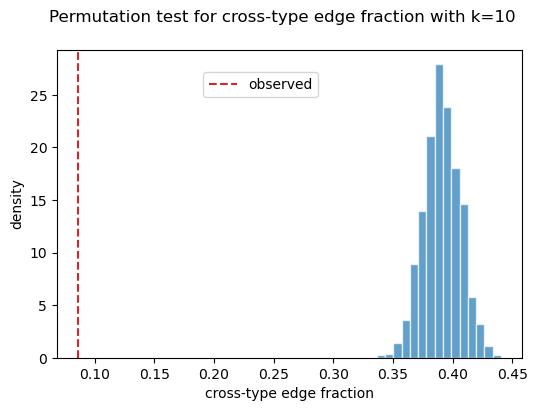

In [197]:
bins = 15
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.axvline(observed, color=cmap(3), linestyle='--', label='observed')
ax.hist(results, bins=bins, color=cmap(0), density=True, edgecolor='white', alpha=0.7)
ax.set_xlabel('cross-type edge fraction')
ax.set_ylabel('density')
ax.legend(frameon=True, bbox_to_anchor=(0.3,0.95), loc='upper left')
fig.suptitle(f"Permutation test for cross-type edge fraction with k={k_core}")



come vogliamo lo shuffle? che generatore random vogliamo usare?


## Configuration model